## Import

In [16]:
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support

In [17]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, Dataset

In [18]:
import os
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
data_path = "/content/drive/My Drive/DIP_project"

Mounted at /content/drive


## Functions

### Merging

In [ ]:
def get_gt_from_txt(gt_file_name):

  # 0 scene
  # 1 dissolve transition
  # 2 hard cut

  with open(gt_file_name) as f:
    array = [[int(x) for x in line.split()] for line in f]
  f.close()
  intervals=np.asarray(array)

  gt=np.ones((intervals[-1,1]+1), dtype=int)
  for i in range(intervals.shape[0]):
    for j in range(intervals[i,0],intervals[i,1]+1):
      gt[j]=0
    if i!=0 and intervals[i-1,1]==intervals[i,0]-1:
      gt[intervals[i-1,1]]=2

  if gt[0]==1:
    gt=gt[1:]

  return gt

In [ ]:
def merge_data_and_gt(idx, errors, gt):
  x=np.zeros((errors.shape), dtype=float)
  y=np.zeros((errors.shape[0]), dtype=float)
  for i in range(errors.shape[0]):
    if idx[i]< gt.shape[0]:
      x[i]=errors[i]
      y[i]=gt[idx[i]]

  return np.squeeze(x),y

In [ ]:
def merge_data_and_gt_more_frames(idx, errors, gt, BUFF_LEN):

  errors_buff = np.zeros((errors.shape[0]- BUFF_LEN, errors.shape[1]*BUFF_LEN))
  idx_buff = np.zeros((errors_buff.shape[0]), dtype = int)

  for i in range(idx_buff.shape[0]):
    errors_buff[i] = np.squeeze(np.concatenate(errors[i: i+BUFF_LEN]))
    idx_buff[i] = idx[i+BUFF_LEN//2]

  x,y = merge_data_and_gt(idx_buff, errors_buff, gt)
  print(x.shape)
  print(y.shape)

  return x,y


### Visualization

In [ ]:
def count_frames_in_video(video_path):
    # Open the video file
    video = cv2.VideoCapture(video_path)

    # Check if video opened successfully
    if not video.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    # Get the total number of frames in the video
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    # Release the video file
    video.release()

    return total_frames

In [ ]:
def plot_colored_data(x, y, title):
    # Separate the data points based on the labels in y
    x_class_0 = x[y == 0]
    x_class_1 = x[y == 1]
    x_class_2 = x[y == 2]

    # Plot the points with different colors based on their class
    plt.scatter(x_class_0[:, 0], x_class_0[:, 1], color='blue', label='Shot', s=2.5)
    plt.scatter(x_class_1[:, 0], x_class_1[:, 1], color='red', label='Gradual transition', s=15)
    plt.scatter(x_class_2[:, 0], x_class_2[:, 1], color='green', label='Abrupt transition', s=15)

    # Set the labels and title
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
def visualize_frames(path, start, end):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        print("Error opening video file")
        return

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    start = max(0, start)
    end = min(frame_count - 1, end)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    for frame_num in range(start, end + 1):
        ret, frame = cap.read()

        if not ret:
            break

        cv2_imshow(frame)



    cap.release()


In [ ]:
# Concatenate frames into a single image
def visualize_frames_sequence(video_path, start_frame, end_frame, mode='horizontal'):

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video file: {video_path}")

    frames = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Validate frame range
    if start_frame < 0 or end_frame >= frame_count or start_frame > end_frame:
        cap.release()
        raise ValueError(f"Invalid frame range: {start_frame} to {end_frame}. Total frames: {frame_count}")

    # Read frames within the specified range
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    for frame_idx in range(start_frame, end_frame + 1):
        ret, frame = cap.read()
        if not ret:
            break
        # Optionally resize frames for consistency
        frame = cv2.resize(frame, (200, 200))
        frames.append(frame)

    cap.release()

    if not frames:
        raise ValueError("No frames were read from the specified range.")

    # Concatenate frames
    if mode == 'horizontal':
        concatenated_image = np.hstack(frames)
    elif mode == 'vertical':
        concatenated_image = np.vstack(frames)
    else:
        raise ValueError("Mode must be 'horizontal' or 'vertical'.")

    # Convert BGR to RGB for displaying with matplotlib
    concatenated_image_rgb = cv2.cvtColor(concatenated_image, cv2.COLOR_BGR2RGB)

    # Display the concatenated image
    plt.figure(figsize=(20, 10) if mode == 'horizontal' else (10, 20))
    plt.imshow(concatenated_image_rgb)
    plt.axis('off')
    plt.show()

## BBC dataset

### Visualization

In [ ]:
# BBC 1

video_path1 = data_path + "/bbc_dataset/bbc_01.mp4"
gt1 = get_gt_from_txt(data_path+"/bbc_gt/01.txt")
idx1 = np.load(data_path+"/bbc_idx/bbc_01_idx.npy")
errors1 = np.load(data_path+"/bbc_errors/bbc_01_errors.npy")

In [ ]:
number_of_frames = count_frames_in_video(video_path1)
print(errors1.shape)
print("Total video frame: ",number_of_frames)
print("Number of buffers: ",idx1.shape[0])
print("Number of labels: ",gt1.shape[0])
print("Number of 0 labels: ",np.sum(gt1 == 0))
print("Number of 1 labels: ",np.sum(gt1 == 1))
print("Hard cut idx: ",np.where( gt1==2)[0])

In [ ]:
# Visualize hc frames

start = 891
end = 892
visualize_frames(video_path1, start, end)

In [ ]:
# Visualize dissolve

start = 649
end = 650
visualize_frames(video_path1, start, end)

In [ ]:
gt1[649] = 2
gt1[632:649] = 1

In [ ]:
# PCA 2D

x_1,y_1=merge_data_and_gt(idx1, errors1, gt1)
print(x_1.shape)
print("Number of labels: ",y_1.shape[0])
print("Number of 0 labels: ",np.sum(y_1 == 0))
print("Number of 1 labels: ",np.sum(y_1 == 1))
print("Hard cut idx: ",np.sum( y_1==2))

np.save(data_path+"/bbc_01_x.npy",x_1)
np.save(data_path+"/bbc_01_y.npy", y_1)

scaler = StandardScaler()
normalized_x_1 = scaler.fit_transform(x_1)
pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(normalized_x_1)

plot_colored_data(principal_components, y_1, "BBC 1")

In [ ]:
BUFF_LEN = 11
x_buff_1, y_buff_1 = merge_data_and_gt_more_frames(idx1, errors1, gt1, BUFF_LEN)
print(x_buff_1.shape)
print("Number of labels: ",y_buff_1.shape)
print("Number of 0 labels: ",np.sum(y_buff_1 == 0))
print("Number of 1 labels: ",np.sum(y_buff_1 == 1))
print("Hard cut idx: ",np.sum( y_buff_1==2))

# PCA 2D
scaler = StandardScaler()
normalized_x_buff_1 = scaler.fit_transform(x_buff_1)
pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(normalized_x_buff_1)

plot_colored_data(principal_components, y_buff_1, "BBC 1")

### Vector extraction

In [ ]:
for i in range(1,12):
  if i < 10:
    idx = np.load(data_path+"/bbc_idx/bbc_0" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_0" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/0" + str(i) +".txt")
  else:
    idx = np.load(data_path+"/bbc_idx/bbc_" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/" + str(i) +".txt")

  x,y=merge_data_and_gt(idx, errors, gt)
  np.save(data_path+"/bbc_vec/bbc_0" + str(i) +"_x.npy",x)
  np.save(data_path+"/bbc_vec/bbc_0" + str(i) +"_y.npy", y)


In [ ]:
BUFF_LEN = 11
for i in range(10,12):
  if i < 10:
    idx = np.load(data_path+"/bbc_idx/bbc_0" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_0" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/0" + str(i) +".txt")
  else:
    idx = np.load(data_path+"/bbc_idx/bbc_" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/" + str(i) +".txt")

  x,y=merge_data_and_gt_more_frames(idx, errors, gt, BUFF_LEN)

  np.save(data_path+"/bbc_vec_buff/bbc_0" + str(i) +"_x.npy",x)
  np.save(data_path+"/bbc_vec_buff/bbc_0" + str(i) +"_y.npy", y)
  print("saving vectors for bbc_0" + str(i) +".npy")


## Models

### SVM

In [59]:
# SVC classification

def train_svc_model(X_train, y_train, X_test, y_test):
    # Create an SVM model with a linear kernel
    svm_model = SVC(kernel='rbf', C = 10, gamma = 'scale', class_weight='balanced', random_state=42)

    # Train the model
    svm_model.fit(X_train, y_train)

    # Predict the labels of the test set
    y_pred = svm_model.predict(X_test)

    # Calculate the accuracy of the model
    accuracy = accuracy_score(y_test, y_pred)
    # f1 score
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    return accuracy, f1, y_pred

### Classifiers

In [4]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, hidden_state = self.rnn(x)
        last_hidden_state = hidden_state[-1]
        return self.classifier(last_hidden_state)

In [19]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, _ = self.lstm(x)     
        pooled = output.mean(dim=1)  
        return self.classifier(pooled)

In [6]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, hidden_state = self.gru(x)
        last_hidden_state = hidden_state[-1]
        return self.classifier(last_hidden_state)

In [20]:
def train_rnn_model(model, train_dataloader, loss_fn, optimizer, device, num_epochs=3):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for x_batch, y_batch in train_dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}")

In [21]:
def evaluate_rnn_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            correct_predictions += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    accuracy = correct_predictions / total_samples
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return accuracy, f1, all_preds, all_labels

In [22]:
# Generate the confusion matrix
def plot_confusion_matrix(y_test, y_pred):
    conf_matrix = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Shot", " Gradual", "Abrupt"])

    # Plot confusion matrix
    disp.plot(cmap=plt.cm.Blues, colorbar=False)
    plt.title("Confusion Matrix")
    plt.show()

    #print("Confusion Matrix:")
    #print(conf_matrix)

In [23]:
def compute_classification_metrics(y_true, y_pred, class_names=None, verbose=True):
    """
    F1 macro + precision/recall/F1 per classe, da usare al posto (o in
    aggiunta) di accuracy e F1 pesato dopo evaluate_rnn_model.
 
    y_true, y_pred: array-like di interi (etichette di classe)
    class_names: opzionale, es. ['shot', 'gradual', 'abrupt'] per un report leggibile
    """
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
 
    if class_names is None:
        class_names = [str(i) for i in range(len(precision))]
 
    if verbose:
        print(f"F1 macro: {f1_macro:.4f}\n")
        print(f"{'Classe':<12}{'Precision':>10}{'Recall':>10}{'F1':>10}{'Support':>10}")
        for name, p, r, f, s in zip(class_names, precision, recall, f1_per_class, support):
            print(f"{name:<12}{p:>10.4f}{r:>10.4f}{f:>10.4f}{s:>10d}")
 
    return {
        'f1_macro': f1_macro,
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1_per_class,
        'support_per_class': support,
    }

## Single video test

In [ ]:
# single video 
seq_len = 11
feature_dim = 135

video = '06'

### SVC

In [ ]:
# SVC
x_1 = np.load(data_path + '/bbc_vec/bbc_' + video + '_x.npy')
y_1 = np.load(data_path + '/bbc_vec/bbc_' + video + '_y.npy')

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x_1,y_1, test_size=0.3, random_state=42)

In [ ]:
accuracy, f1, y_pred = train_svc_model(X_train, y_train, X_test, y_test)
print(f"SVC Accuracy: {accuracy * 100:.2f}%")
print(f"SVC F1 Score: {f1:.4f}")
plot_confusion_matrix(y_test, y_pred)

### Simple RNN

In [ ]:
# RNN
x_buff = np.load(data_path + '/bbc_vec_buff/bbc_' + video + '_x.npy')
y_buff = np.load(data_path + '/bbc_vec_buff/bbc_' + video + '_y.npy')


# Create tensors
x_tensor = torch.tensor(x_buff, dtype=torch.float32).reshape(-1, seq_len, feature_dim)
y_tensor = torch.tensor(y_buff, dtype=torch.long)

# Divide into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    x_tensor, y_tensor, test_size=0.3, random_state=42, stratify=y_tensor
)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Train batches:", len(train_dataloader))
print("Test batches:", len(test_dataloader))

In [ ]:
# train and evaluate RNN model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = feature_dim
hidden_size = 64
num_layers = 2
num_classes = 3

model_rnn = RNNClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

print(model_rnn)
print(f"Trainable parameters: {sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)}")

In [ ]:
# train and evaluate RNN model
train_rnn_model(model_rnn, train_dataloader, loss_fn, optimizer, device, num_epochs=3)
#evaluate the model
accuracy, f1, all_preds, all_labels = evaluate_rnn_model(model_rnn, test_dataloader, device)
print(f"RNN Accuracy: {accuracy * 100:.2f}%")
print(f"RNN F1 Score: {f1:.4f}")
plot_confusion_matrix(all_labels, all_preds)

## Aggregating videos

In [9]:
training_video = list(range(1, 5))  
validation_video = [8, 9]
test_video = [10]

In [10]:
torch.manual_seed(42)
np.random.seed(42)

### Window Dataset test

In [50]:
def load_raw_video_features(video_list, mmap=True):
    """
    Carica le feature grezze (non bufferizzate) per una lista di video.
 
    Usa lo zero-padding a due cifre (es. 01, 02, ..., 10, 11), quindi
    funziona correttamente anche per i video con indice >= 10, a
    differenza di 'bbc_0' + str(i) usato altrove nel notebook.
 
    Con mmap=True i file vengono mappati da disco invece che caricati
    interamente in RAM: utile se stai aggregando molti video insieme.
    """
    mmap_mode = 'r' if mmap else None
    features, labels = [], []
    for i in video_list:
        x = np.load(f"{data_path}/bbc_vec/bbc_0" + str(i) + "_x.npy", mmap_mode=mmap_mode)
        y = np.load(f"{data_path}/bbc_vec/bbc_0" + str(i) + "_y.npy", mmap_mode=mmap_mode)
        features.append(x)
        labels.append(y)
    return features, labels

In [51]:
class VideoWindowDataset(Dataset):
    """
    Dataset che costruisce finestre di frame consecutivi al volo.
 
    Ogni item e' una finestra di `buff_len` frame presi dallo STESSO video
    (le finestre non attraversano mai il confine tra due video, come nel
    comportamento originale di merge_data_and_gt_more_frames), con label
    associata al frame centrale della finestra.
 
    Non serve pre-flattenare e poi fare reshape come nel notebook originale:
    la finestra viene restituita gia' nella forma (buff_len, feature_dim)
    che le RNN si aspettano con batch_first=True.
    """
 
    def __init__(self, video_features, video_labels, buff_len=11):
        assert len(video_features) == len(video_labels), \
            "Il numero di array di feature e di label deve coincidere"
 
        self.buff_len = buff_len
        self.features = video_features  # tengo i riferimenti originali (anche mmap) per evitare copie
        self.labels = video_labels
 
        # numero di finestre disponibili per ciascun video
        self.windows_per_video = [
            max(0, x.shape[0] - buff_len + 1) for x in self.features
        ]
        self.cumulative = np.cumsum([0] + self.windows_per_video)
 
    def __len__(self):
        return int(self.cumulative[-1])
 
    def _locate(self, global_idx):
        video_idx = int(np.searchsorted(self.cumulative, global_idx, side='right') - 1)
        local_idx = int(global_idx - self.cumulative[video_idx])
        return video_idx, local_idx
 
    def __getitem__(self, global_idx):
        video_idx, local_idx = self._locate(global_idx)
        x = self.features[video_idx]
        y = self.labels[video_idx]
 
        # slicing base (non fancy indexing): niente copia in memoria finche' non serve davvero
        window = np.asarray(x[local_idx: local_idx + self.buff_len], dtype=np.float32)
        center_label = int(y[local_idx + self.buff_len // 2])
 
        return torch.from_numpy(window), torch.tensor(center_label, dtype=torch.long)
 
    def get_window_labels(self):
        """
        Etichette dei frame centrali di ogni finestra, senza materializzare
        le finestre stesse. Serve per compute_class_weight o per costruire
        i pesi di un WeightedRandomSampler.
        """
        all_labels = []
        for y, n_windows in zip(self.labels, self.windows_per_video):
            if n_windows <= 0:
                continue
            centers = np.arange(n_windows) + self.buff_len // 2
            all_labels.append(np.asarray(y[centers]))
        return np.concatenate(all_labels) if all_labels else np.array([], dtype=np.int64)

In [52]:

training_video = [1, 2]
validation_video = [8, 9]
test_video = [10]
BUFF_LEN = 11

# --- costruzione dataset lazy, niente file _buff.npy da generare/salvare ---
train_x, train_y = load_raw_video_features(training_video)
train_dataset = VideoWindowDataset(train_x, train_y, buff_len=BUFF_LEN)

val_x, val_y = load_raw_video_features(validation_video)
val_dataset = VideoWindowDataset(val_x, val_y, buff_len=BUFF_LEN)


# --- opzione A: class_weight nella loss (come fai gia' ora) ---
window_labels = train_dataset.get_window_labels()
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(window_labels),
    y=window_labels,
)
# da passare come weight a nn.CrossEntropyLoss(weight=torch.tensor(class_weights, ...))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = feature_dim
hidden_size = 64
num_layers = 2
num_classes = 3

model_rnn = RNNClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
).to(device)


train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(device))


optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

print(model_rnn)
print(f"Trainable parameters: {sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)}")

print(f"Finestre di training: {len(train_dataset)}")
print(f"Finestre di validation: {len(val_dataset)}")


RNNClassifier(
  (rnn): RNN(135, 64, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)
Trainable parameters: 21379
Finestre di training: 145908
Finestre di validation: 147618


Epoch 1/3, Loss: 0.3485
Epoch 2/3, Loss: 0.2456
Epoch 3/3, Loss: 0.1919
RNN Accuracy: 81.76%
RNN F1 Score: 0.8926


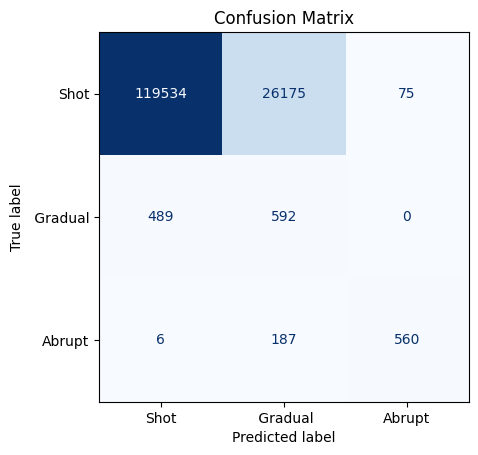

In [53]:
# train and evaluate RNN model
train_rnn_model(model_rnn, train_dataloader, loss_fn, optimizer, device, num_epochs=3)
#evaluate the model
accuracy, f1, all_preds, all_labels = evaluate_rnn_model(model_rnn, val_dataloader, device)
print(f"RNN Accuracy: {accuracy * 100:.2f}%")
print(f"RNN F1 Score: {f1:.4f}")
plot_confusion_matrix(all_labels, all_preds)

### SVC

In [56]:
def load_data_from_videos(video_list):
    x_data = []
    y_data = []
    for i in video_list:
        x = np.load(data_path + '/bbc_vec/bbc_0' + str(i) + '_x.npy')
        y = np.load(data_path + '/bbc_vec/bbc_0' + str(i) + '_y.npy')
        x_data.append(x)
        y_data.append(y)
    print(f"Concatenating data from videos: {video_list}")
    return np.concatenate(x_data), np.concatenate(y_data)

In [61]:
# Aggregating data from videos (NOT NECESSARY IF YOU ALREADY HAVE THE .npy FILES)
X_train, y_train = load_data_from_videos(training_video)
X_val, y_val     = load_data_from_videos(validation_video)
#X_test, y_test   = load_data_from_videos(test_video)

'''
# save the data to .npy files
np.save(data_path + '/bbc_vec/bbc_train_x.npy', X_train)
np.save(data_path + '/bbc_vec/bbc_train_y.npy', y_train)
np.save(data_path + '/bbc_vec/bbc_val_x.npy', X_val)
np.save(data_path + '/bbc_vec/bbc_val_y.npy', y_val)
np.save(data_path + '/bbc_vec/bbc_test_x.npy', X_test)
np.save(data_path + '/bbc_vec/bbc_test_y.npy', y_test)
'''

Concatenating data from videos: [1, 2]
Concatenating data from videos: [8, 9]


"\n# save the data to .npy files\nnp.save(data_path + '/bbc_vec/bbc_train_x.npy', X_train)\nnp.save(data_path + '/bbc_vec/bbc_train_y.npy', y_train)\nnp.save(data_path + '/bbc_vec/bbc_val_x.npy', X_val)\nnp.save(data_path + '/bbc_vec/bbc_val_y.npy', y_val)\nnp.save(data_path + '/bbc_vec/bbc_test_x.npy', X_test)\nnp.save(data_path + '/bbc_vec/bbc_test_y.npy', y_test)\n"

In [ ]:
# load final data 
X_train = np.load(data_path + '/bbc_vec/bbc_train_x.npy')
y_train = np.load(data_path + '/bbc_vec/bbc_train_y.npy')
#X_val = np.load(data_path + '/bbc_vec/bbc_val_x.npy')
#y_val = np.load(data_path + '/bbc_vec/bbc_val_y.npy')
X_test = np.load(data_path + '/bbc_vec/bbc_test_x.npy')
y_test = np.load(data_path + '/bbc_vec/bbc_test_y.npy')

In [ ]:
# Train the model SVC
accuracy, f1, y_pred = train_svc_model(X_train, y_train, X_val, y_val)
print(f"SVC Accuracy: {accuracy * 100:.2f}%")
print(f"SVC F1 Score: {f1:.4f}")
plot_confusion_matrix(y_val, y_pred)


### RNN

In [ ]:
import gc

def load_data_from_videos_tensor(video_list, seq_len=11, feature_dim=135):
    x_data = []
    y_data = []
    for i in video_list:
        #print(f"Loading video {i}...")
        x = np.load(data_path + '/bbc_vec_buff/bbc_0' + str(i) + '_x.npy', mmap_mode='r')
        y = np.load(data_path + '/bbc_vec_buff/bbc_0' + str(i) + '_y.npy', mmap_mode='r')
        #print(f"Video {i} loaded: x shape = {x.shape}, y shape = {y.shape}")
        x_data.append(x)
        y_data.append(y)
        #print(f"Video {i} appended: x_data length = {len(x_data)}, y_data length = {len(y_data)}")
        del x, y

           
    print(f"Concatenating data from {len(video_list)} videos...")
    X_concat = np.concatenate(x_data)
    Y_concat = np.concatenate(y_data)

    #print(f"Data concatenated: X shape = {X_concat.shape}, Y shape = {Y_concat.shape}")

    del x_data, y_data
    gc.collect() 

    # Create tensors
    x_tensor = torch.tensor(X_concat, dtype=torch.float32).reshape(-1, seq_len, feature_dim)
    y_tensor = torch.tensor(Y_concat, dtype=torch.long)

    print(f"Tensors created: x_tensor shape = {x_tensor.shape}, y_tensor shape = {y_tensor.shape}")

    return x_tensor, y_tensor

In [12]:
# refining and saving data (NOT NECESSARY IF YOU ALREADY HAVE THE .pt FILES)
X_train, y_train = load_data_from_videos_tensor(training_video)
X_val, y_val     = load_data_from_videos_tensor(validation_video)
X_test, y_test   = load_data_from_videos_tensor(test_video)

'''
# save the data to .pt files
torch.save(X_train, data_path + '/bbc_vec_buff/bbc_train_x.pt')
torch.save(y_train, data_path + '/bbc_vec_buff/bbc_train_y.pt')
torch.save(X_val, data_path + '/bbc_vec_buff/bbc_val_x.pt')
torch.save(y_val, data_path + '/bbc_vec_buff/bbc_val_y.pt')
torch.save(X_test, data_path + '/bbc_vec_buff/bbc_test_x.pt')
torch.save(y_test, data_path + '/bbc_vec_buff/bbc_test_y.pt')
'''

Loading video 1...
Video 1 loaded: x shape = (73833, 1485), y shape = (73833,)
Video 1 appended: x_data length = 1, y_data length = 1
Loading video 2...
Video 2 loaded: x shape = (72073, 1485), y shape = (72073,)
Video 2 appended: x_data length = 2, y_data length = 2
Loading video 3...
Video 3 loaded: x shape = (73883, 1485), y shape = (73883,)
Video 3 appended: x_data length = 3, y_data length = 3
Loading video 4...
Video 4 loaded: x shape = (73533, 1485), y shape = (73533,)
Video 4 appended: x_data length = 4, y_data length = 4
Concatenating data from 4 videos...


KeyboardInterrupt: 

In [ ]:
batch_size = 32

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train, y_train)
eval_dataset = TensorDataset(X_val, y_val)
#test_dataset = TensorDataset(X_test, y_test)


train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)
#test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
# train and evaluate RNN model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = 135
hidden_size = 64
num_layers = 2
learning_rate = 1e-3
num_classes = 3

model_rnn = LSTMClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
).to(device)


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.numpy()),
    y=y_train.numpy()
)

# Conversione in tensore da passare poi alla CrossEntropyLoss
weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(device))


optimizer = torch.optim.Adam(model_rnn.parameters(), lr=learning_rate)

print(model_rnn)
print(f"Trainable parameters: {sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)}")

LSTMClassifier(
  (lstm): LSTM(135, 64, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)
Trainable parameters: 84931


Epoch 1/3, Loss: 0.2535
Epoch 2/3, Loss: 0.1385
Epoch 3/3, Loss: 0.1060
RNN Accuracy: 92.91%
RNN F1 Score: 0.9562


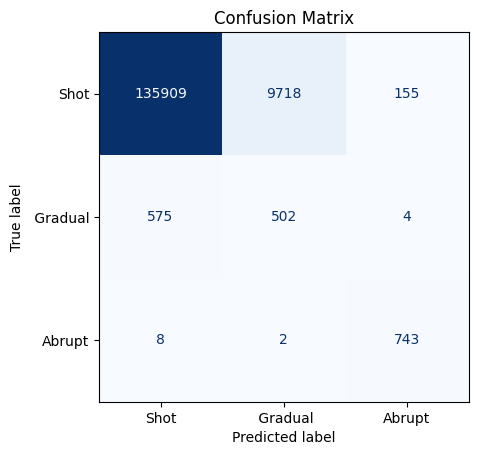

F1 macro: 0.6499

Classe       Precision    Recall        F1   Support
Shot            0.9957    0.9323    0.9630    145782
Gradual         0.0491    0.4644    0.0888      1081
Abrupt          0.8237    0.9867    0.8979       753


{'f1_macro': 0.6498897162601507,
 'precision_per_class': array([0.99572869, 0.04910976, 0.82372506]),
 'recall_per_class': array([0.93227559, 0.46438483, 0.98671979]),
 'f1_per_class': array([0.96295798, 0.08882598, 0.8978852 ]),
 'support_per_class': array([145782,   1081,    753])}

In [19]:
# train and evaluate RNN model
train_rnn_model(model_rnn, train_dataloader, loss_fn, optimizer, device, num_epochs=3)
#evaluate the model
accuracy, f1, all_preds, all_labels = evaluate_rnn_model(model_rnn, eval_dataloader, device)
print(f"RNN Accuracy: {accuracy * 100:.2f}%")
print(f"RNN F1 Score: {f1:.4f}")
plot_confusion_matrix(all_labels, all_preds)
compute_classification_metrics(all_labels, all_preds, class_names=["Shot", "Gradual", "Abrupt"], verbose=True)

F1 macro: 0.6444

Classe       Precision    Recall        F1   Support
Shot            0.9957    0.9146    0.9535    145782
Gradual         0.0400    0.4746    0.0738      1081
Abrupt          0.8425    0.9801    0.9061       753


{'f1_macro': 0.6444329377637693,
 'precision_per_class': array([0.9957136 , 0.03999065, 0.84246575]),
 'recall_per_class': array([0.91463967, 0.47456059, 0.98007968]),
 'f1_per_class': array([0.95345628, 0.07376519, 0.90607735]),
 'support_per_class': array([145782,   1081,    753])}

## Random search

In [14]:
import pandas as pd
def sample_random_config(param_space, rng):
    config = {}
    for key, values in param_space.items():
        choice = rng.choice(values)
        if isinstance(choice, np.generic):
            choice = choice.item()  # numpy scalar -> tipo nativo Python
        config[key] = choice
    return config


def run_random_search(
    training_video,
    validation_video,
    param_space,
    #load_raw_video_features,
    #VideoWindowDataset,
    Classifier,
    train_rnn_model,
    evaluate_rnn_model,
    compute_classification_metrics,
    data_path,
    n_iter=10,
    buff_len=11,
    num_epochs=3,
    input_size=135,
    num_classes=3,
    seed=42,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rng = np.random.default_rng(seed)

    '''
    # split fisso, caricato una sola volta per tutta la ricerca
    train_x, train_y = load_raw_video_features(data_path, training_video)
    val_x, val_y = load_raw_video_features(data_path, validation_video)

    train_dataset = VideoWindowDataset(train_x, train_y, buff_len=buff_len)
    val_dataset = VideoWindowDataset(val_x, val_y, buff_len=buff_len)

    window_labels = train_dataset.get_window_labels()
    '''

    X_train, y_train = load_data_from_videos_tensor(training_video)
    X_val, y_val     = load_data_from_videos_tensor(validation_video)

    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train, y_train)
    eval_dataset = TensorDataset(X_val, y_val)

    

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train.numpy()),
        y=y_train.numpy()
    )
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    results = []
    tried_configs = set()

    for it in range(n_iter):
        # evita di ripetere per caso una combinazione gia' provata
        params = None
        for _ in range(20):
            candidate = sample_random_config(param_space, rng)
            config_key = tuple(sorted(candidate.items()))
            if config_key not in tried_configs:
                tried_configs.add(config_key)
                params = candidate
                break
        if params is None:
            print(f"[iter {it}] spazio di ricerca esaurito, interrompo qui.")
            break

        batch_size = params.get("batch_size", 32)
        #train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        #val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

        # stesso seed per ogni configurazione: isola l'effetto dell'iperparametro
        # dalla variabilita' dovuta all'inizializzazione casuale dei pesi
        torch.manual_seed(seed)

        model = LSTMClassifier(
            input_size=input_size,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            num_classes=num_classes,
        ).to(device)

        loss_fn = nn.CrossEntropyLoss(weight=weights_tensor.to(device))
        optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

        train_rnn_model(model, train_dataloader, loss_fn, optimizer, device, num_epochs=num_epochs)
        _, _, all_preds, all_labels = evaluate_rnn_model(model, eval_dataloader, device)

        metrics = compute_classification_metrics(all_labels, all_preds, verbose=False)

        results.append({
            "iteration": it,
            **params,
            "f1_macro": metrics["f1_macro"],
            "recall_per_class": metrics["recall_per_class"],
            "precision_per_class": metrics["precision_per_class"],
        })

        print(f"[iter {it}] {params} -> metrics: f1_macro={metrics['f1_macro']:.4f}, recall={metrics['recall_per_class']}, precision={metrics['precision_per_class']}")

    results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
    return results, results_df




In [ ]:

training_video = [1, 2, 3, 4]
validation_video = [8, 9]
# test_video = [10]  # resta fuori dalla ricerca, usato solo per la valutazione finale

feature_dim = 135  # come gia' definito nel notebook

param_space = {
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
    "lr": [1e-3, 5e-4],
    "batch_size": [16, 32, 64],
}

results, results_df = run_random_search(
        training_video=training_video,
        validation_video=validation_video,
        param_space=param_space,
        #load_raw_video_features=load_raw_video_features,
        #VideoWindowDataset=VideoWindowDataset,
        Classifier=LSTMClassifier,
        train_rnn_model=train_rnn_model,
        evaluate_rnn_model=evaluate_rnn_model,
        compute_classification_metrics=compute_classification_metrics,
        data_path=data_path,
        input_size=feature_dim,
        n_iter=10,
        num_epochs=3,
    )
print(results_df[["hidden_size", "num_layers", "lr", "batch_size", "f1_macro"]])


Loading video 1...
Video 1 loaded: x shape = (73833, 1485), y shape = (73833,)
Video 1 appended: x_data length = 1, y_data length = 1
Loading video 2...
Video 2 loaded: x shape = (72073, 1485), y shape = (72073,)
Video 2 appended: x_data length = 2, y_data length = 2
Loading video 3...
Video 3 loaded: x shape = (73883, 1485), y shape = (73883,)
Video 3 appended: x_data length = 3, y_data length = 3
Loading video 4...
Video 4 loaded: x shape = (73533, 1485), y shape = (73533,)
Video 4 appended: x_data length = 4, y_data length = 4
Concatenating data from 4 videos...
Data concatenated: X shape = (293322, 1485), Y shape = (293322,)
Tensors created: x_tensor shape = torch.Size([293322, 11, 135]), y_tensor shape = torch.Size([293322])
Loading video 8...
Video 8 loaded: x shape = (73808, 1485), y shape = (73808,)
Video 8 appended: x_data length = 1, y_data length = 1
Loading video 9...
Video 9 loaded: x shape = (73808, 1485), y shape = (73808,)
Video 9 appended: x_data length = 2, y_data len

In [27]:
print(results_df[["hidden_size", "num_layers", "lr", "batch_size", "f1_macro"]])

   hidden_size  num_layers      lr  batch_size  f1_macro
7           64           1  0.0005          16  0.678673
9          128           2  0.0010          32  0.675927
2           32           1  0.0005          64  0.655459
0           32           2  0.0005          32  0.655459
6          128           2  0.0005          64  0.654339
1           64           2  0.0010          64  0.642181
5           64           1  0.0010          64  0.642181
3          128           2  0.0001          64  0.640805
8           32           2  0.0001          16  0.630763
4           64           1  0.0001          32  0.625586


## Grid Search

In [25]:
"""
Grid search esaustiva degli iperparametri con la loss base (CrossEntropyLoss
pesata, gia' in uso), split fisso training/validation. Si appoggia a
load_raw_video_features e VideoWindowDataset (lazy_windowing.py) e a
compute_classification_metrics (focal_loss_and_metrics.py) gia' scritti.

A differenza di random_search.py, qui si esplorano TUTTE le combinazioni di
param_grid (itertools.product), non un campione casuale: pensata per essere
usata dopo aver gia' ristretto lo spazio di ricerca (es. escludendo valori
gia' individuati come chiaramente peggiori, come lr=0.0001 o hidden_size=32).
"""

import itertools


def run_grid_search(
    training_video,
    validation_video,
    param_grid,
    ModelClass,
    train_rnn_model,
    evaluate_rnn_model,
    compute_classification_metrics,
    num_epochs=3,
    input_size=135,
    num_classes=3,
    seed=42,
):
    """
    ModelClass: la classe del modello da istanziare (es. LSTMClassifier),
    deve accettare (input_size, hidden_size, num_layers, num_classes).

    param_grid: dict di liste, es.
        {"hidden_size": [64, 128], "num_layers": [1, 2],
         "lr": [5e-4, 1e-3], "batch_size": [16, 32, 64]}
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    X_train, y_train = load_data_from_videos_tensor(training_video)
    X_val, y_val     = load_data_from_videos_tensor(validation_video)

    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train, y_train)
    eval_dataset = TensorDataset(X_val, y_val)

    

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train.numpy()),
        y=y_train.numpy()
    )
    
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    

    keys = list(param_grid.keys())
    all_combinations = list(itertools.product(*param_grid.values()))
    print(f"Combinazioni totali da provare: {len(all_combinations)}\n")

    results = []

    for config_id, values in enumerate(all_combinations):
        params = dict(zip(keys, values))

        batch_size = params.get("batch_size", 32)
        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

        # stesso seed per ogni configurazione: isola l'effetto degli iperparametri
        # dalla variabilita' dovuta all'inizializzazione casuale dei pesi
        torch.manual_seed(seed)

        model = ModelClass(
            input_size=input_size,
            hidden_size=params["hidden_size"],
            num_layers=params["num_layers"],
            num_classes=num_classes,
        ).to(device)

        loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)
        optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

        train_rnn_model(model, train_dataloader, loss_fn, optimizer, device, num_epochs=num_epochs)
        _, _, all_preds, all_labels = evaluate_rnn_model(model, eval_dataloader, device)

        metrics = compute_classification_metrics(all_labels, all_preds, verbose=False)

        results.append({
            "config_id": config_id,
            **params,
            "f1_macro": metrics["f1_macro"],
            "recall_per_class": metrics["recall_per_class"],
            "precision_per_class": metrics["precision_per_class"],
        })

        print(f"[{config_id + 1}/{len(all_combinations)}] {params} -> F1 macro = {metrics['f1_macro']:.4f}")

    results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
    return results, results_df




In [ ]:
# ---------------------------------------------------------------------------
# Esempio d'uso nel notebook
# ---------------------------------------------------------------------------

training_video = [1, 2]
validation_video = [8, 9]
# test_video = [10]  # resta fuori, usato solo per la valutazione finale


# spazio gia' ristretto sulla base dell'analisi precedente:
# esclusi hidden_size=32 e lr=0.0001, entrambi chiaramente peggiori
param_grid = {
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
    "lr": [5e-4, 1e-3],
    "batch_size": [16, 32, 64],
}
# 2 x 2 x 2 x 3 = 24 combinazioni totali

results, results_df = run_grid_search(
        training_video=training_video,
        validation_video=validation_video,
        param_grid=param_grid,
        ModelClass=LSTMClassifier,
        train_rnn_model=train_rnn_model,
        evaluate_rnn_model=evaluate_rnn_model,
        compute_classification_metrics=compute_classification_metrics,
        num_epochs=3,
)
print(results_df[["hidden_size", "num_layers", "lr", "batch_size", "f1_macro"]])
   

Loading video 1...
Video 1 loaded: x shape = (73833, 1485), y shape = (73833,)
Video 1 appended: x_data length = 1, y_data length = 1
Loading video 2...
Video 2 loaded: x shape = (72073, 1485), y shape = (72073,)
Video 2 appended: x_data length = 2, y_data length = 2
Concatenating data from 2 videos...
Data concatenated: X shape = (145906, 1485), Y shape = (145906,)
Tensors created: x_tensor shape = torch.Size([145906, 11, 135]), y_tensor shape = torch.Size([145906])
Loading video 8...
Video 8 loaded: x shape = (73808, 1485), y shape = (73808,)
Video 8 appended: x_data length = 1, y_data length = 1
Loading video 9...
Video 9 loaded: x shape = (73808, 1485), y shape = (73808,)
Video 9 appended: x_data length = 2, y_data length = 2
Concatenating data from 2 videos...
Data concatenated: X shape = (147616, 1485), Y shape = (147616,)
Tensors created: x_tensor shape = torch.Size([147616, 11, 135]), y_tensor shape = torch.Size([147616])
Combinazioni totali da provare: 24

Epoch 1/3, Loss: 0.3

## SVM classification

In [ ]:
# SVC classification

# Create an SVM model with a linear kernel
svm_model = SVC(kernel='rbf', C = 10, gamma = 'scale')

# Train the model
svm_model.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svm_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# f1 score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")




In [ ]:
print(y_train.shape)

In [ ]:
svc = SVC(kernel='rbf', C = 10, gamma = 'scale', class_weight='balanced')

# Train the model
svc.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svc.predict(x_6)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_6, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_6, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Shot", " Gradual", "Abrupt"])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## RNN classification

### Simple RNN classification

In [ ]:
seq_len = 11
feature_dim = 135

video = '01'
x_buff = load(data_path + '/bbc_vec_buff/bbc_' + video + '_x_1.npy')
y_buff = load(data_path + '/bbc_vec_buff/bbc_' + video + '_y_1.npy')


x_tensor = torch.tensor(x_buff, dtype=torch.float32).reshape(-1, seq_len, feature_dim)
y_tensor = torch.tensor(y_buff, dtype=torch.long)

print(x_tensor.shape)
print(y_tensor.shape)

dataset = TensorDataset(x_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(dataset))
print(len(dataloader))

### Aggregating classification models

In [ ]:
input_size = feature_dim
hidden_size = 64
num_layers = 2
num_classes = 3

model_specs = [
    (
        "RNN",
        RNNClassifier,
        {"input_size": input_size, "hidden_size": hidden_size, "num_layers": num_layers, "num_classes": num_classes},
    ),
    (
        "GRU",
        GRUClassifier,
        {"input_size": input_size, "hidden_size": hidden_size, "num_layers": num_layers, "num_classes": num_classes},
    ),
    (
        "LSTM",
        LSTMClassifier,
        {"input_size": input_size, "hidden_size": hidden_size, "num_layers": num_layers, "num_classes": num_classes},
    ),
]


def train_model(model, train_loader, device, loss_fn, optimizer, epochs=3):
    history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.4f}")

    return history


def evaluate_model(model, eval_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in eval_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            correct_predictions += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    accuracy = correct_predictions / total_samples
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    return accuracy, cm


In [ ]:
comparison_results = []

for model_name, model_class, model_kwargs in model_specs:
    comparison_model = model_class(**model_kwargs).to(device)
    comparison_loss_fn = nn.CrossEntropyLoss()
    comparison_optimizer = torch.optim.Adam(comparison_model.parameters(), lr=1e-3)

    print(f"\nTraining {model_name}")
    train_model(comparison_model, dataloader, device, comparison_loss_fn, comparison_optimizer, epochs=3)

    comparison_accuracy, comparison_cm = evaluate_model(comparison_model, eval_dataloader, device)
    comparison_results.append((model_name, comparison_accuracy, comparison_cm))

    print(f"{model_name} Accuracy: {comparison_accuracy:.4f}")
    print(comparison_cm)

In [ ]:
print("\nSummary")
for model_name, model_accuracy, _ in comparison_results:
    print(f"{model_name}: {model_accuracy:.4f}")